In [1]:
%matplotlib inline

In [2]:
import os
import copy
import json
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

In [3]:
# =========================================================
# CONFIGURATION
# =========================================================
TRAIN_CSV = "dataset_updated/annotations/train.csv"
VAL_CSV   = "dataset_updated/annotations/val.csv"
TEST_CSV  = "dataset_updated/annotations/test.csv"

BASE_OUTPUT_DIR = "model_outputs_binary_only"

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS = 70
PATIENCE = 10
LR = 1e-4
WEIGHT_DECAY = 1e-4
THRESHOLD = 0.5
SEED = 42

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_LIST = [
    "resnet50",
    "resnet101",
    "densenet121",
    "efficientnet_b0",
    #"efficientnet_b3",
    #"mobilenet_v3_large",
    #"convnext_tiny",
    #"vgg16",
]

# Choose models here
# SELECTED_MODELS = ["resnet50"]
SELECTED_MODELS = MODEL_LIST

os.makedirs(BASE_OUTPUT_DIR, exist_ok=True)

In [4]:
# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
torch.backends.cudnn.benchmark = True

In [5]:
# =========================================================
# DATASET
# =========================================================
class TornadoBinaryDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["filepath"]

        image = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)

        label = torch.tensor(float(row["binary_label"]), dtype=torch.float32)

        return {
            "image": image,
            "label": label,
            "filepath": img_path
        }

In [6]:
# =========================================================
# TRANSFORMS
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

In [7]:
# =========================================================
# MODEL BUILDER
# =========================================================
def build_model(model_name):
    if model_name == "resnet50":
        from torchvision.models import resnet50, ResNet50_Weights
        model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 1)
        )

    elif model_name == "resnet101":
        from torchvision.models import resnet101, ResNet101_Weights
        model = resnet101(weights=ResNet101_Weights.IMAGENET1K_V2)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 1)
        )

    elif model_name == "densenet121":
        from torchvision.models import densenet121, DenseNet121_Weights
        model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        in_features = model.classifier.in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 1)
        )

    elif model_name == "efficientnet_b0":
        from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 1)
        )

    elif model_name == "efficientnet_b3":
        from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
        model = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 1)
        )

    elif model_name == "mobilenet_v3_large":
        from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights
        model = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.IMAGENET1K_V2)
        in_features = model.classifier[3].in_features
        model.classifier = nn.Sequential(
            nn.Linear(model.classifier[0].in_features, model.classifier[0].out_features),
            nn.Hardswish(),
            nn.Dropout(0.5),
            nn.Linear(in_features, 1)
        )

    elif model_name == "convnext_tiny":
        from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
        model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        in_features = model.classifier[2].in_features
        model.classifier = nn.Sequential(
            model.classifier[0],
            model.classifier[1],
            nn.Dropout(0.5),
            nn.Linear(in_features, 1)
        )

    elif model_name == "vgg16":
        from torchvision.models import vgg16, VGG16_Weights
        model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 1)
        )

    else:
        raise ValueError(f"Unsupported model: {model_name}")

    return model


In [8]:
# =========================================================
# METRICS
# =========================================================
def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob, dtype=float)
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred)
    }

    if len(np.unique(y_true)) == 2:
        metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
    else:
        metrics["roc_auc"] = np.nan

    return metrics, y_pred


In [9]:
# =========================================================
# TRAIN / EVAL
# =========================================================
def train_one_epoch(model, loader, optimizer, criterion, device, threshold=0.5):
    model.train()
    running_loss = 0.0
    y_true, y_prob = [], []

    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        probs = torch.sigmoid(logits).detach().cpu().numpy().flatten()
        y_prob.extend(probs.tolist())
        y_true.extend(labels.detach().cpu().numpy().flatten().tolist())

    metrics, _ = compute_binary_metrics(y_true, y_prob, threshold=threshold)
    metrics["loss"] = running_loss / max(len(loader), 1)
    return metrics


def evaluate_labeled(model, loader, criterion, device, threshold=0.5):
    model.eval()
    running_loss = 0.0
    y_true, y_prob = [], []
    filepaths = []

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True).unsqueeze(1)

            logits = model(images)
            loss = criterion(logits, labels)
            running_loss += loss.item()

            probs = torch.sigmoid(logits).cpu().numpy().flatten()
            y_prob.extend(probs.tolist())
            y_true.extend(labels.cpu().numpy().flatten().tolist())
            filepaths.extend(batch["filepath"])

    metrics, y_pred = compute_binary_metrics(y_true, y_prob, threshold=threshold)
    metrics["loss"] = running_loss / max(len(loader), 1)

    pred_df = pd.DataFrame({
        "filepath": filepaths,
        "true_label": np.array(y_true).astype(int),
        "pred_prob": np.array(y_prob, dtype=float),
        "pred_label": y_pred.astype(int)
    })

    # Safety check to avoid stale/wrong notebook state issues
    precision_check = precision_score(
        pred_df["true_label"], pred_df["pred_label"], zero_division=0
    )
    recall_check = recall_score(
        pred_df["true_label"], pred_df["pred_label"], zero_division=0
    )
    f1_check = f1_score(
        pred_df["true_label"], pred_df["pred_label"], zero_division=0
    )

    metrics["precision"] = precision_check
    metrics["recall"] = recall_check
    metrics["f1"] = f1_check

    return metrics, pred_df

In [10]:
# =========================================================
# PLOTTING
# =========================================================
def plot_training_curves(history_df, output_dir, model_name):
    if history_df.empty:
        return

    # 1) Training Loss vs Validation Loss
    plt.figure(figsize=(10, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} Training Loss vs Validation Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "loss_curve.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # 2) Training Accuracy vs Validation Accuracy
    plt.figure(figsize=(10, 5))
    plt.plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy")
    plt.plot(history_df["epoch"], history_df["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} Training Accuracy vs Validation Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "accuracy_curve.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # 3) Training F1 vs Validation F1
    plt.figure(figsize=(10, 5))
    plt.plot(history_df["epoch"], history_df["train_f1"], label="Train F1")
    plt.plot(history_df["epoch"], history_df["val_f1"], label="Validation F1")
    plt.xlabel("Epoch")
    plt.ylabel("F1 Score")
    plt.title(f"{model_name} Training F1 vs Validation F1")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "f1_curve.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # 4) Precision and Recall vs Epoch
    plt.figure(figsize=(10, 5))
    plt.plot(history_df["epoch"], history_df["train_precision"], label="Train Precision")
    plt.plot(history_df["epoch"], history_df["val_precision"], label="Val Precision")
    plt.plot(history_df["epoch"], history_df["train_recall"], label="Train Recall")
    plt.plot(history_df["epoch"], history_df["val_recall"], label="Val Recall")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title(f"{model_name} Precision and Recall vs Epoch")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "precision_recall_curve.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_confusion_matrix_figure(y_true, y_pred, output_path, class_names=("Non-Tornado", "Tornado")):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, str(cm[i, j]),
                horizontalalignment="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black"
            )

    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()



In [11]:
# =========================================================
# LOAD CSVs
# =========================================================
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Using device:", DEVICE)
print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

print("\nTrain label counts:")
print(train_df["binary_label"].value_counts().sort_index())

print("\nVal label counts:")
print(val_df["binary_label"].value_counts().sort_index())

print("\nTest label counts:")
print(test_df["binary_label"].value_counts().sort_index())

train_label_counts = train_df["binary_label"].value_counts().to_dict()
num_neg = train_label_counts.get(0, 0)
num_pos = train_label_counts.get(1, 0)
pos_weight_value = num_neg / num_pos if num_pos > 0 else 1.0

print("\nNegative:", num_neg)
print("Positive:", num_pos)
print("pos_weight:", pos_weight_value)

Using device: cuda
Train: 8674
Val: 700
Test: 700

Train label counts:
binary_label
0    4300
1    4374
Name: count, dtype: int64

Val label counts:
binary_label
0    350
1    350
Name: count, dtype: int64

Test label counts:
binary_label
0    350
1    350
Name: count, dtype: int64

Negative: 4300
Positive: 4374
pos_weight: 0.9830818472793782


In [12]:
# =========================================================
# DATALOADERS
# =========================================================
train_dataset = TornadoBinaryDataset(train_df, transform=train_transform)
val_dataset = TornadoBinaryDataset(val_df, transform=eval_transform)
test_dataset = TornadoBinaryDataset(test_df, transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

In [13]:
# ==========================
# CONFUSION MATRIX FUNCTION
# ==========================

def plot_confusion_matrix_figure(y_true, y_pred, output_path, class_names=("Non-Tornado", "Tornado")):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, str(cm[i, j]),
                horizontalalignment="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black"
            )

    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

In [14]:

# =========================================================
# MAIN RUN FUNCTION
# =========================================================
def run_single_model(model_name):
    print(f"\n{'='*70}")
    print(f"Running model: {model_name}")
    print(f"{'='*70}")

    output_dir = os.path.join(BASE_OUTPUT_DIR, model_name)
    os.makedirs(output_dir, exist_ok=True)

    model = build_model(model_name).to(DEVICE)

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32).to(DEVICE)
    )

    optimizer = optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS
    )

    best_state = copy.deepcopy(model.state_dict())
    best_val_f1 = -1.0
    best_epoch = -1
    best_train_metrics = None
    best_val_metrics = None
    patience_counter = 0
    history = []

    start_time = time.time()

    for epoch in range(EPOCHS):
        epoch_idx = epoch + 1

        train_metrics = train_one_epoch(
            model, train_loader, optimizer, criterion, DEVICE, threshold=THRESHOLD
        )
        val_metrics, val_pred_df = evaluate_labeled(
            model, val_loader, criterion, DEVICE, threshold=THRESHOLD
        )

        row = {
            "epoch": epoch_idx,
            "lr": optimizer.param_groups[0]["lr"],

            "train_loss": float(train_metrics["loss"]),
            "train_acc": float(train_metrics["accuracy"]),
            "train_precision": float(train_metrics["precision"]),
            "train_recall": float(train_metrics["recall"]),
            "train_f1": float(train_metrics["f1"]),
            "train_roc_auc": float(train_metrics["roc_auc"]) if not pd.isna(train_metrics["roc_auc"]) else np.nan,

            "val_loss": float(val_metrics["loss"]),
            "val_acc": float(val_metrics["accuracy"]),
            "val_precision": float(val_metrics["precision"]),
            "val_recall": float(val_metrics["recall"]),
            "val_f1": float(val_metrics["f1"]),
            "val_roc_auc": float(val_metrics["roc_auc"]) if not pd.isna(val_metrics["roc_auc"]) else np.nan,
        }
        history.append(row)

        print(
            f"Epoch {epoch_idx:03d} | "
            f"LR {optimizer.param_groups[0]['lr']:.6f} | "
            f"Train Loss {train_metrics['loss']:.4f} | "
            f"Train Acc {train_metrics['accuracy']:.4f} | "
            f"Train F1 {train_metrics['f1']:.4f} | "
            f"Val Loss {val_metrics['loss']:.4f} | "
            f"Val Acc {val_metrics['accuracy']:.4f} | "
            f"Val Precision {val_metrics['precision']:.4f} | "
            f"Val Recall {val_metrics['recall']:.4f} | "
            f"Val F1 {val_metrics['f1']:.4f}"
        )

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_epoch = epoch_idx
            best_state = copy.deepcopy(model.state_dict())
            best_train_metrics = copy.deepcopy(train_metrics)
            best_val_metrics = copy.deepcopy(val_metrics)
            patience_counter = 0

            torch.save(best_state, os.path.join(output_dir, f"best_{model_name}.pth"))
            val_pred_df.to_csv(os.path.join(output_dir, "best_val_predictions.csv"), index=False)
        else:
            patience_counter += 1

        scheduler.step()

        if patience_counter >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch_idx}")
            break

    elapsed = time.time() - start_time

    history_df = pd.DataFrame(history)
    history_df.to_csv(os.path.join(output_dir, "training_log.csv"), index=False)

    print("\nHistory preview:")
    print(history_df[[
        "epoch", "train_precision", "val_precision",
        "train_recall", "val_recall",
        "train_f1", "val_f1"
    ]].tail())

    plot_training_curves(history_df, output_dir, model_name)

    model.load_state_dict(best_state)

    test_metrics, test_pred_df = evaluate_labeled(
        model, test_loader, criterion, DEVICE, threshold=THRESHOLD
    )
    test_pred_df.to_csv(os.path.join(output_dir, "test_predictions.csv"), index=False)

    plot_confusion_matrix_figure(
        y_true=test_pred_df["true_label"].values,
        y_pred=test_pred_df["pred_label"].values,
        output_path=os.path.join(output_dir, "confusion_matrix.png"),
        class_names=("Non-Tornado", "Tornado")
    )

    summary = {
        "model": model_name,
        "best_epoch": best_epoch,
        "runtime_sec": elapsed,

        "best_train_loss": best_train_metrics["loss"] if best_train_metrics else None,
        "best_train_accuracy": best_train_metrics["accuracy"] if best_train_metrics else None,
        "best_train_precision": best_train_metrics["precision"] if best_train_metrics else None,
        "best_train_recall": best_train_metrics["recall"] if best_train_metrics else None,
        "best_train_f1": best_train_metrics["f1"] if best_train_metrics else None,
        "best_train_roc_auc": best_train_metrics["roc_auc"] if best_train_metrics else None,

        "best_val_loss": best_val_metrics["loss"] if best_val_metrics else None,
        "best_val_accuracy": best_val_metrics["accuracy"] if best_val_metrics else None,
        "best_val_precision": best_val_metrics["precision"] if best_val_metrics else None,
        "best_val_recall": best_val_metrics["recall"] if best_val_metrics else None,
        "best_val_f1": best_val_metrics["f1"] if best_val_metrics else None,
        "best_val_roc_auc": best_val_metrics["roc_auc"] if best_val_metrics else None,

        "test_loss": test_metrics["loss"],
        "test_accuracy": test_metrics["accuracy"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
        "test_f1": test_metrics["f1"],
        "test_roc_auc": test_metrics["roc_auc"],
        "tn_fp_fn_tp": test_metrics["confusion_matrix"].tolist(),
        "num_parameters": sum(p.numel() for p in model.parameters()),
    }

    with open(os.path.join(output_dir, "final_summary.json"), "w") as f:
        json.dump(summary, f, indent=2)

    with open(os.path.join(output_dir, "final_summary.txt"), "w") as f:
        f.write(f"Model: {model_name}\n")
        f.write(f"Best Epoch: {best_epoch}\n")
        f.write(f"Runtime (sec): {elapsed:.2f}\n\n")

        f.write("Best Train Metrics:\n")
        f.write(f"Loss: {summary['best_train_loss']:.4f}\n" if summary["best_train_loss"] is not None else "Loss: None\n")
        f.write(f"Accuracy: {summary['best_train_accuracy']:.4f}\n" if summary["best_train_accuracy"] is not None else "Accuracy: None\n")
        f.write(f"Precision: {summary['best_train_precision']:.4f}\n" if summary["best_train_precision"] is not None else "Precision: None\n")
        f.write(f"Recall: {summary['best_train_recall']:.4f}\n" if summary["best_train_recall"] is not None else "Recall: None\n")
        f.write(f"F1: {summary['best_train_f1']:.4f}\n" if summary["best_train_f1"] is not None else "F1: None\n")
        f.write(f"ROC-AUC: {summary['best_train_roc_auc']:.4f}\n\n" if summary["best_train_roc_auc"] is not None else "ROC-AUC: None\n\n")

        f.write("Best Validation Metrics:\n")
        f.write(f"Loss: {summary['best_val_loss']:.4f}\n" if summary["best_val_loss"] is not None else "Loss: None\n")
        f.write(f"Accuracy: {summary['best_val_accuracy']:.4f}\n" if summary["best_val_accuracy"] is not None else "Accuracy: None\n")
        f.write(f"Precision: {summary['best_val_precision']:.4f}\n" if summary["best_val_precision"] is not None else "Precision: None\n")
        f.write(f"Recall: {summary['best_val_recall']:.4f}\n" if summary["best_val_recall"] is not None else "Recall: None\n")
        f.write(f"F1: {summary['best_val_f1']:.4f}\n" if summary["best_val_f1"] is not None else "F1: None\n")
        f.write(f"ROC-AUC: {summary['best_val_roc_auc']:.4f}\n\n" if summary["best_val_roc_auc"] is not None else "ROC-AUC: None\n\n")

        f.write("Test Metrics:\n")
        f.write(f"Loss: {test_metrics['loss']:.4f}\n")
        f.write(f"Accuracy: {test_metrics['accuracy']:.4f}\n")
        f.write(f"Precision: {test_metrics['precision']:.4f}\n")
        f.write(f"Recall: {test_metrics['recall']:.4f}\n")
        f.write(f"F1: {test_metrics['f1']:.4f}\n")
        f.write(f"ROC-AUC: {test_metrics['roc_auc']:.4f}\n")
        f.write(f"Confusion Matrix:\n{test_metrics['confusion_matrix']}\n\n")

        f.write("Classification Report:\n")
        f.write(classification_report(
            test_pred_df["true_label"],
            test_pred_df["pred_label"],
            target_names=["non-tornado", "tornado"],
            digits=4
        ))

    print("\nFinal test metrics:")
    print(summary)

    return summary


Running model: resnet50
Epoch 001 | LR 0.000100 | Train Loss 0.1870 | Train Acc 0.9216 | Train F1 0.9229 | Val Loss 2.5210 | Val Acc 0.5000 | Val Precision 0.5000 | Val Recall 0.7743 | Val F1 0.6076
Epoch 002 | LR 0.000100 | Train Loss 0.0390 | Train Acc 0.9887 | Train F1 0.9888 | Val Loss 3.6502 | Val Acc 0.5000 | Val Precision 0.5000 | Val Recall 0.9114 | Val F1 0.6457
Epoch 003 | LR 0.000100 | Train Loss 0.0177 | Train Acc 0.9947 | Train F1 0.9947 | Val Loss 2.7356 | Val Acc 0.5000 | Val Precision 0.5000 | Val Recall 0.8286 | Val F1 0.6237
Epoch 004 | LR 0.000100 | Train Loss 0.0124 | Train Acc 0.9960 | Train F1 0.9960 | Val Loss 2.8803 | Val Acc 0.5000 | Val Precision 0.5000 | Val Recall 0.7914 | Val F1 0.6128
Epoch 005 | LR 0.000099 | Train Loss 0.0023 | Train Acc 0.9998 | Train F1 0.9998 | Val Loss 3.4591 | Val Acc 0.5000 | Val Precision 0.5000 | Val Recall 0.8371 | Val F1 0.6261
Epoch 006 | LR 0.000099 | Train Loss 0.0167 | Train Acc 0.9975 | Train F1 0.9975 | Val Loss 3.4409 |

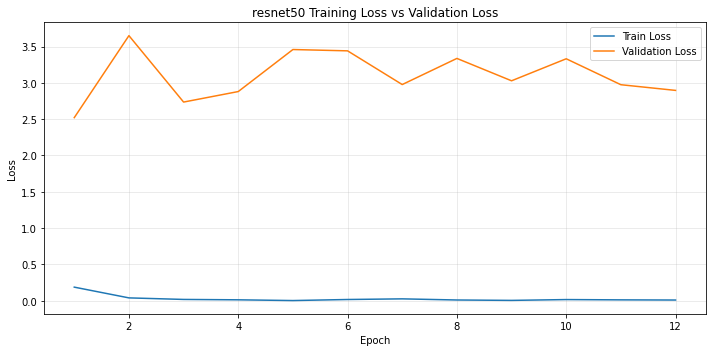

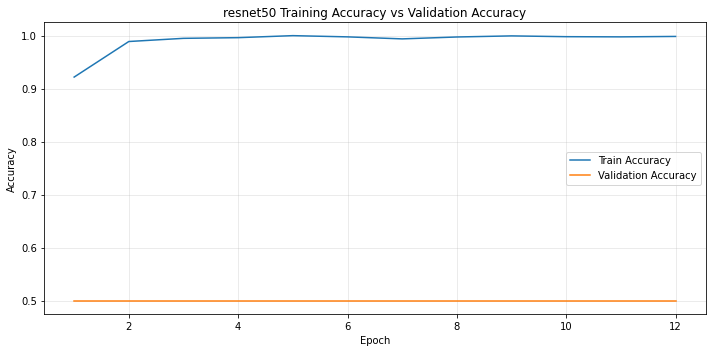

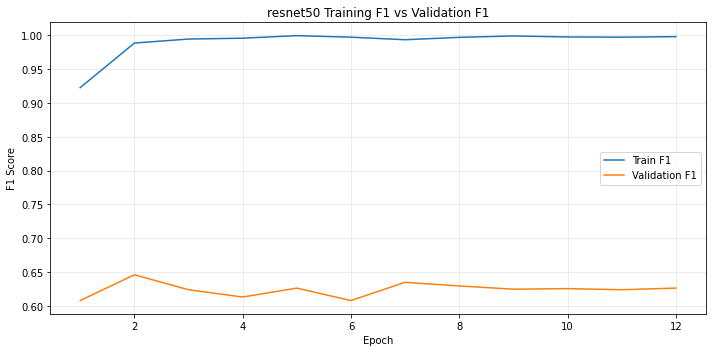

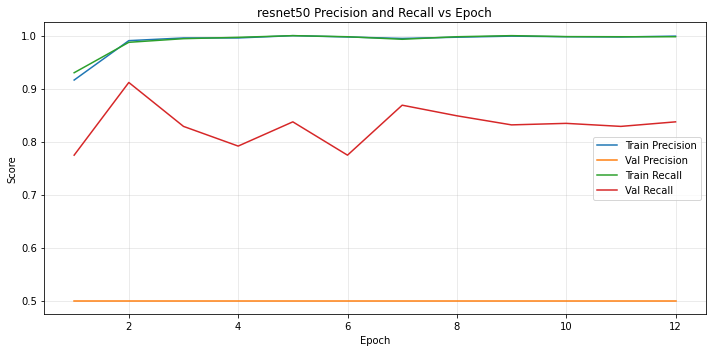

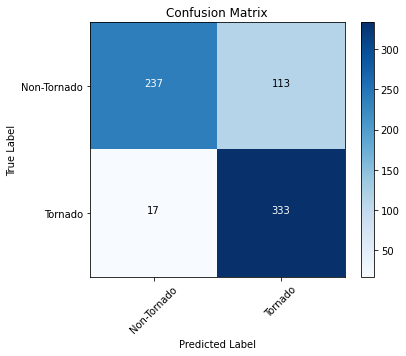


Final test metrics:
{'model': 'resnet50', 'best_epoch': 2, 'runtime_sec': 650.1644809246063, 'best_train_loss': 0.03898950775585357, 'best_train_accuracy': 0.9887018676504497, 'best_train_precision': 0.9903669724770642, 'best_train_recall': 0.9871970736168267, 'best_train_f1': 0.9887794824822532, 'best_train_roc_auc': np.float64(0.9991771142374072), 'best_val_loss': 3.650228337808089, 'best_val_accuracy': 0.5, 'best_val_precision': 0.5, 'best_val_recall': 0.9114285714285715, 'best_val_f1': 0.645748987854251, 'best_val_roc_auc': np.float64(0.4999551020408164), 'test_loss': 0.8112709793177518, 'test_accuracy': 0.8142857142857143, 'test_precision': 0.7466367713004485, 'test_recall': 0.9514285714285714, 'test_f1': 0.8366834170854272, 'test_roc_auc': np.float64(0.9136408163265306), 'tn_fp_fn_tp': [[237, 113], [17, 333]], 'num_parameters': 23510081}

Running model: resnet101
Epoch 001 | LR 0.000100 | Train Loss 0.1569 | Train Acc 0.9341 | Train F1 0.9349 | Val Loss 2.7127 | Val Acc 0.5000 |

In [ ]:
# =========================================================
# RUN SELECTED MODELS
# =========================================================
all_results = []

for model_name in SELECTED_MODELS:
    summary = run_single_model(model_name)
    all_results.append(summary)

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(by=["test_f1", "test_roc_auc"], ascending=False)
results_df.to_csv(os.path.join(BASE_OUTPUT_DIR, "all_model_results.csv"), index=False)

print("\n" + "=" * 70)
print("ALL RESULTS")
print("=" * 70)
print(results_df)